# Graph2vec + TimeDistributed MLP — Dissertation Evaluation Suite

Three conditions evaluated over 10 random seeds per product:
- **Baseline** (`ablate_z = 'baseline'`): pure MLP, no graph structure
- **Ablated Graph2vec** (`ablate_z = 'True'`): graph is built but embedding *z* is zeroed out
- **Proposed Graph2vec** (`ablate_z = 'False'`): full model — graph2vec embedding fed into MLP

In [25]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

In [26]:

# ── Load & sanitise ───────────────────────────────────────────────────────────
df_raw = pd.read_csv("TimeDistributedMLP/graph2vec_mlp2_finalresults.csv")

# Drop the experiment-time sentinel row
df = df_raw[df_raw['item_id'] != 'TOTAL_EXPERIMENT_TIME_SECONDS'].copy()
df['item_id'] = df['item_id'].astype(int)

# Replace name r2_score for composite_score, which is what we actually care about. The original r2_score column was a misnomer.
df.rename(columns={'r2_score': 'composite_score'}, inplace=True)
df['composite_score'] = (0.50 * df['rmse']) + (0.25 * df['mae']) + (0.25 * df['bias'].abs())
# Three conditions — ablate_z is stored as a string in the CSV
BASELINE = df[df['ablate_z'] == 'baseline'].copy()   # pure MLP, no graph
ABLATED  = df[df['ablate_z'] == 'True'].copy()        # graph built, z ablated
PROPOSED = df[df['ablate_z'] == 'False'].copy()       # full graph2vec + MLP

METRICS       = ['rmse', 'mae', 'composite_score', 'pocid']
METRIC_LABELS = {'rmse': 'RMSE ↓', 'mae': 'MAE ↓', 'composite_score': 'R² ↓', 'pocid': 'POCID ↑'}
# For each metric: does a *lower* or *higher* value mean better performance?
BETTER        = {'rmse': 'lower', 'mae': 'lower', 'composite_score': 'lower', 'pocid': 'higher'}

PALETTE = {
    'Baseline\n(MLP)':        '#7f8c8d',
    'Ablated\nGraph2vec':     '#f39c12',
    'Proposed\nGraph2vec':    '#27ae60',
}
df.to_csv("evaluation_suite.csv", index=False)
print(f"Products : {df['item_id'].nunique()}")
print(f"Seeds    : {df['seed'].nunique()}  {sorted(df['seed'].unique())}")
print(f"Rows     — Baseline: {len(BASELINE)}, Ablated: {len(ABLATED)}, Proposed: {len(PROPOSED)}")

Products : 61
Seeds    : 10  [42, 1000, 26008, 213626, 555555, 907969, 5219788, 13451285, 23616558, 618626816]
Rows     — Baseline: 610, Ablated: 610, Proposed: 609


In [27]:

# ── Export appendix_product_summary to LaTeX ──────────────────────────────────
import os

latex_prod_path = os.path.join(os.path.dirname(os.path.abspath("evaluation_suite2.ipynb")), "appendix_product_summary.tex")

# Rename columns to be more LaTeX friendly before saving if desired
prod_latex_df = prod_merged.copy()

latex_str = prod_latex_df.to_latex(
    index=False,
    float_format="%.4f",
    caption="Product-Level Summary Statistics and Relative Improvements",
    label="tab:appendix_product_summary",
    column_format="l" + "c" * (len(prod_latex_df.columns) - 1),
    # Optional: If the table is too wide, you might want to use longtable or resizebox in your actual TeX document
)

with open(latex_prod_path, "w") as f:
    f.write(latex_str)

print(f"Saved product-level LaTeX table to: {latex_prod_path}")


Saved product-level LaTeX table to: c:\Users\Andre Silva\Desktop\Dissertation25-26\GNN\Graph2vec_FixedThreshold\appendix_product_summary.tex


## Step 1 — Shapiro-Wilk Normality Test on Per-Product Mean Differences

For each comparison and metric:
1. Compute the difference `Proposed − Competitor` for every `(item_id, seed)` pair.
2. Average those differences **per product** across the 10 seeds → **n = 61 observations** (one per product).
3. Run Shapiro-Wilk on those 61 values.

> **Why per-product means, not all 609 pairs?**
> Shapiro-Wilk on n=609 is massively overpowered — trivial, dissertation-irrelevant deviations will be flagged. Aggregating to product means gives a sensible sample size that matches the statistical unit you actually care about.
>
> **Decision rule:**  p > 0.05 → Normal → use paired t-test.  p ≤ 0.05 → Non-normal → use Wilcoxon signed-rank.

In [28]:
key = ['item_id', 'seed']

pairs_pb = PROPOSED[key + METRICS].merge(BASELINE[key + METRICS], on=key, suffixes=('_prop', '_base'))
pairs_pa = PROPOSED[key + METRICS].merge(ABLATED[key + METRICS],  on=key, suffixes=('_prop', '_abla'))

COMPARISONS = {
    'Proposed vs Baseline': (pairs_pb, '_base'),
    'Proposed vs Ablated':  (pairs_pa, '_abla'),
}

# normality_results[(comparison, metric)] = True  → differences are normal
normality_results = {}

# Also store the per-product diff vectors for Q-Q plots in the next cell
diff_vectors = {}

alpha_sw = 0.05

print(f"{'='*68}")
print(f"SHAPIRO-WILK NORMALITY TEST  (H₀: differences are normally distributed)")
print(f"Unit: per-product mean difference across 10 seeds  →  n = {pairs_pb['item_id'].nunique()} products")
print(f"α = {alpha_sw}")
print(f"{'='*68}")

rows_sw = []
for comp_name, (pairs_df, suffix) in COMPARISONS.items():
    print(f"\n  {'─'*30}  {comp_name}  {'─'*30}")
    for m in METRICS:
        # 1. seed-level differences
        diffs = pairs_df.assign(diff=pairs_df[f'{m}_prop'] - pairs_df[f'{m}{suffix}'])
        # 2. per-product mean
        per_prod = diffs.groupby('item_id')['diff'].mean()

        stat, p = stats.shapiro(per_prod)
        is_normal = p > alpha_sw
        verdict = "NORMAL      → paired t-test" if is_normal else "NOT NORMAL  → Wilcoxon"
        flag    = "✓" if is_normal else "✗"

        normality_results[(comp_name, m)] = is_normal
        diff_vectors[(comp_name, m)]      = per_prod.values

        lbl = METRIC_LABELS[m]
        print(f"    {lbl:<12}  W = {stat:.4f}   p = {p:.4f}   {flag}  {verdict}")
        rows_sw.append({
            'Comparison': comp_name,
            'Metric':     lbl,
            'W':          round(stat, 4),
            'p-value':    round(p, 4),
            'Normal?':    '✓ Yes' if is_normal else '✗ No',
            'Recommended test': 'Paired t-test' if is_normal else 'Wilcoxon signed-rank',
        })

print(f"\n{'='*68}")

sw_table = pd.DataFrame(rows_sw)
display(sw_table.style
    .hide(axis='index')
    .set_caption("Shapiro-Wilk results — per-product mean differences (n = 61)")
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size','13px'), ('font-weight','bold')]},
        {'selector': 'th',      'props': [('text-align','center'), ('background-color','#2f527f'), ('color','white')]},
    ])
    .applymap(lambda v: 'color: #27ae60; font-weight:bold' if v == '✓ Yes'
              else ('color: #c0392b; font-weight:bold' if v == '✗ No' else ''),
              subset=['Normal?'])
)

SHAPIRO-WILK NORMALITY TEST  (H₀: differences are normally distributed)
Unit: per-product mean difference across 10 seeds  →  n = 61 products
α = 0.05

  ──────────────────────────────  Proposed vs Baseline  ──────────────────────────────
    RMSE ↓        W = 0.8330   p = 0.0000   ✗  NOT NORMAL  → Wilcoxon
    MAE ↓         W = 0.8222   p = 0.0000   ✗  NOT NORMAL  → Wilcoxon
    R² ↓          W = 0.8904   p = 0.0001   ✗  NOT NORMAL  → Wilcoxon
    POCID ↑       W = 0.9010   p = 0.0001   ✗  NOT NORMAL  → Wilcoxon

  ──────────────────────────────  Proposed vs Ablated  ──────────────────────────────
    RMSE ↓        W = 0.8219   p = 0.0000   ✗  NOT NORMAL  → Wilcoxon
    MAE ↓         W = 0.7660   p = 0.0000   ✗  NOT NORMAL  → Wilcoxon
    R² ↓          W = 0.8412   p = 0.0000   ✗  NOT NORMAL  → Wilcoxon
    POCID ↑       W = 0.9804   p = 0.4364   ✓  NORMAL      → paired t-test



Comparison,Metric,W,p-value,Normal?,Recommended test
Proposed vs Baseline,RMSE ↓,0.833000,0.000000,✗ No,Wilcoxon signed-rank
Proposed vs Baseline,MAE ↓,0.822200,0.000000,✗ No,Wilcoxon signed-rank
Proposed vs Baseline,R² ↓,0.890400,0.000100,✗ No,Wilcoxon signed-rank
Proposed vs Baseline,POCID ↑,0.901000,0.000100,✗ No,Wilcoxon signed-rank
Proposed vs Ablated,RMSE ↓,0.821900,0.000000,✗ No,Wilcoxon signed-rank
Proposed vs Ablated,MAE ↓,0.766000,0.000000,✗ No,Wilcoxon signed-rank
Proposed vs Ablated,R² ↓,0.841200,0.000000,✗ No,Wilcoxon signed-rank
Proposed vs Ablated,POCID ↑,0.980400,0.436400,✓ Yes,Paired t-test


In [ ]:

# ── Appendix table per product (item_id) ──────────────────────────────────────
import pandas as pd
import os

# Compute mean and standard deviation per item_id (across the 10 seeds)
def _agg_by_product(cond_df):
    return cond_df.groupby('item_id')[METRICS].agg(['mean', 'std']).reset_index()

prod_base = _agg_by_product(BASELINE)
prod_abla = _agg_by_product(ABLATED)
prod_prop = _agg_by_product(PROPOSED)

# Flatten columns: e.g. from ('rmse', 'mean') to 'rmse_mean'
def _flatten_cols(df, prefix):
    df.columns = ['item_id'] + [f"{m}_{stat}" for m, stat in df.columns[1:]]
    return df

prod_base = _flatten_cols(prod_base, 'base')
prod_abla = _flatten_cols(prod_abla, 'abla')
prod_prop = _flatten_cols(prod_prop, 'prop')

# Merge all conditions together
prod_merged = prod_base.merge(prod_abla, on='item_id', suffixes=('_base', '_abla'))
prod_merged = prod_merged.merge(prod_prop, on='item_id')

# Rename the final columns to have consistent suffixes
new_cols = []
for c in prod_merged.columns:
    if c == 'item_id':
        new_cols.append(c)
    elif c.endswith('_mean') or c.endswith('_std'):
        # Because we merged three dfs, the last one didn't get a suffix
        new_cols.append(f"{c}_prop")
    else:
        new_cols.append(c)
prod_merged.columns = new_cols

# Append relative improvements
for m in METRICS:
    # Proposed is the last merged piece
    prop_mean = prod_merged[f"{m}_mean_prop"]
    base_mean = prod_merged[f"{m}_mean_base"]
    abla_mean = prod_merged[f"{m}_mean_abla"]
    
    if BETTER[m] == 'lower':
        ri_vs_base = (base_mean - prop_mean) / base_mean.abs() * 100
        ri_vs_abla = (abla_mean - prop_mean) / abla_mean.abs() * 100
        min_base= min(ri)
    else:
        ri_vs_base = (prop_mean - base_mean) / base_mean.abs() * 100
        ri_vs_abla = (prop_mean - abla_mean) / abla_mean.abs() * 100
        
    prod_merged[f"RI_{NICE_NAMES[m]}_vs_Base (%)"] = ri_vs_base
    prod_merged[f"RI_{NICE_NAMES[m]}_vs_Abla (%)"] = ri_vs_abla

# Clean up the dataframe for display and export
order_cols = ['item_id']
for m in METRICS:
    order_cols.extend([
        f"{m}_mean_base", f"{m}_std_base",
        f"{m}_mean_abla", f"{m}_std_abla",
        f"{m}_mean_prop", f"{m}_std_prop",
        f"RI_{NICE_NAMES[m]}_vs_Base (%)",
        f"RI_{NICE_NAMES[m]}_vs_Abla (%)"
    ])
prod_merged = prod_merged[order_cols]

# Save to CSV
csv_prod_path = os.path.join(os.path.dirname(os.path.abspath("evaluation_suite2.ipynb")), "appendix_product_summary.csv")
prod_merged.to_csv(csv_prod_path, index=False)
print(f"Saved product-level summary to: {csv_prod_path}")

# Display the first few rows nicely
display(prod_merged.style.format(precision=4))

Saved product-level summary to: c:\Users\Andre Silva\Desktop\Dissertation25-26\GNN\Graph2vec_FixedThreshold\appendix_product_summary.csv


,item_id,rmse_mean_base,rmse_std_base,rmse_mean_abla,rmse_std_abla,rmse_mean_prop,rmse_std_prop,RI_RMSE_vs_Base (%),RI_RMSE_vs_Abla (%),mae_mean_base,mae_std_base,mae_mean_abla,mae_std_abla,mae_mean_prop,mae_std_prop,RI_MAE_vs_Base (%),RI_MAE_vs_Abla (%),composite_score_mean_base,composite_score_std_base,composite_score_mean_abla,composite_score_std_abla,composite_score_mean_prop,composite_score_std_prop,RI_Composite Score_vs_Base (%),RI_Composite Score_vs_Abla (%),pocid_mean_base,pocid_std_base,pocid_mean_abla,pocid_std_abla,pocid_mean_prop,pocid_std_prop,RI_POCID_vs_Base (%),RI_POCID_vs_Abla (%)
0,278,10.9608,0.6996,10.9581,0.6833,10.7554,0.8437,1.8735,1.8490,8.1105,0.3881,7.9957,0.3490,8.1356,0.4245,-0.3093,-1.7497,7.9251,0.5183,7.9589,0.5960,7.7861,0.6506,1.7532,2.1710,0.5658,0.0186,0.5612,0.0194,0.5704,0.0219,0.8140,1.6413
1,457,9.6588,1.0589,10.1974,0.7238,10.2000,0.7958,-5.6034,-0.0263,7.9161,0.8879,8.3485,0.7033,8.2844,0.6670,-4.6520,0.7676,8.2489,1.0623,8.7075,0.7666,8.6378,0.8649,-4.7147,0.8008,0.5039,0.0288,0.4980,0.0196,0.5125,0.0197,1.6971,2.9062
2,1325,8.8418,0.5328,8.4921,0.4241,8.6629,0.4907,2.0235,-2.0111,6.7264,0.3212,6.4402,0.2663,6.5472,0.3500,2.6640,-1.6614,6.5044,0.4415,6.3182,0.3822,6.4181,0.5041,1.3258,-1.5818,0.5414,0.0263,0.5487,0.0260,0.5414,0.0279,0.0000,-1.3189
3,6032,10.2652,1.2452,10.8733,0.8031,12.5112,1.1100,-21.8805,-15.0640,6.6253,0.4800,6.6598,0.3468,7.7907,0.7281,-17.5901,-16.9814,7.0219,0.9646,7.3462,0.6506,8.5975,0.8863,-22.4388,-17.0339,0.5789,0.0158,0.5888,0.0285,0.5934,0.0230,2.5000,0.7821
4,13544,42.0117,3.2845,41.2266,2.9099,38.5734,2.8198,8.1842,6.4357,32.6028,2.8776,31.7818,2.2216,29.7055,1.8819,8.8865,6.5330,30.8754,2.1629,30.0940,2.4306,28.2740,2.5099,8.4255,6.0477,0.6112,0.0185,0.6283,0.0224,0.6112,0.0440,0.0000,-2.7225
5,16920,9.5655,0.1405,9.4898,0.1001,9.6705,0.2061,-1.0973,-1.9038,7.4884,0.2695,7.4705,0.1106,7.6492,0.2525,-2.1477,-2.3918,6.9972,0.3043,6.9075,0.1782,7.1376,0.3563,-2.0076,-3.3311,0.5849,0.0375,0.5750,0.0156,0.5684,0.0099,-2.8121,-1.1442
6,18568,22.1854,0.3569,22.0111,0.3075,22.0037,0.3599,0.8191,0.0334,17.4068,0.1974,17.3093,0.2411,17.3040,0.2694,0.5909,0.0309,17.0299,0.4631,16.7559,0.4039,16.7575,0.4325,1.5996,-0.0096,0.4546,0.0153,0.4322,0.0194,0.4322,0.0261,-4.9204,-0.0000
7,25032,12.1312,0.1206,12.1023,0.1904,12.3578,0.3022,-1.8672,-2.1104,9.4995,0.1232,9.4078,0.1405,9.7546,0.3139,-2.6862,-3.6867,8.6682,0.2145,8.7670,0.3337,9.0070,0.3906,-3.9089,-2.7384,0.5283,0.0108,0.5368,0.0173,0.5303,0.0125,0.3736,-1.2255
8,26002,37.9348,7.2531,38.2492,7.0496,39.2345,8.5066,-3.4259,-2.5759,20.4088,2.9086,20.9277,2.9324,21.1131,3.2932,-3.4510,-0.8861,27.7562,4.9754,27.8954,5.0462,27.9597,6.1214,-0.7332,-0.2305,0.5066,0.0515,0.5296,0.0516,0.5164,0.0548,1.9481,-2.4845
9,26008,42.6759,2.2727,41.9127,1.2533,43.6819,2.6997,-2.3572,-4.2211,22.6639,1.9489,21.9870,1.0212,23.7425,2.1423,-4.7593,-7.9844,27.7227,1.7398,27.3252,0.9593,28.6838,2.1550,-3.4666,-4.9717,0.6816,0.0250,0.6822,0.0254,0.6822,0.0161,0.0965,0.0000


In [33]:
# ── Top 5 / Bottom 5 products by Mean RI vs min(Baseline, Ablated) ──────────
# Uses prod_merged from the cell above (mean across 10 seeds already computed)

highlights = prod_merged[['item_id']].copy()

# Conservative reference per product: the BETTER of the two competitors
highlights['ref_rmse']  = prod_merged[['rmse_mean_base', 'rmse_mean_abla']].min(axis=1)
highlights['ref_mae']   = prod_merged[['mae_mean_base',  'mae_mean_abla']].min(axis=1)
highlights['prop_rmse'] = prod_merged['rmse_mean_prop']
highlights['prop_mae']  = prod_merged['mae_mean_prop']

# RI: positive means Proposed beats the stronger competitor (lower error = better)
highlights['RI_RMSE (%)'] = (highlights['ref_rmse'] - highlights['prop_rmse']) / highlights['ref_rmse'] * 100
highlights['RI_MAE (%)']  = (highlights['ref_mae']  - highlights['prop_mae'])  / highlights['ref_mae']  * 100
highlights['Mean RI (%)'] = (highlights['RI_RMSE (%)'] + highlights['RI_MAE (%)']) / 2

highlights = highlights.sort_values('Mean RI (%)', ascending=False).reset_index(drop=True)

n_win = (highlights['Mean RI (%)'] > 0).sum()
n_tot = len(highlights)
print(f"Overall mean RI across {n_tot} products : {highlights['Mean RI (%)'].mean():+.4f}%")
print(f"Products where Proposed wins (RI > 0)   : {n_win}/{n_tot} ({100*n_win/n_tot:.1f}%)\n")

top5    = highlights.head(5).assign(Group='Top 5 (Best)')
bottom5 = highlights.tail(5).assign(Group='Bottom 5 (Worst)')
show_df = pd.concat([top5, bottom5], ignore_index=True)

show_df = show_df[['Group', 'item_id', 'ref_rmse', 'prop_rmse', 'RI_RMSE (%)',
                    'ref_mae', 'prop_mae', 'RI_MAE (%)', 'Mean RI (%)']].rename(columns={
    'item_id':   'Product',
    'ref_rmse':  'Ref RMSE',
    'prop_rmse': 'Prop RMSE',
    'ref_mae':   'Ref MAE',
    'prop_mae':  'Prop MAE',
})

ri_cols = ['RI_RMSE (%)', 'RI_MAE (%)', 'Mean RI (%)']

display(show_df.style
    .hide(axis='index')
    .format(precision=4, subset=['Ref RMSE', 'Prop RMSE', 'Ref MAE', 'Prop MAE'])
    .format('{:+.2f}%', subset=ri_cols)
    .background_gradient(subset=['Mean RI (%)'], cmap='RdYlGn', vmin=-10, vmax=10)
    .applymap(
        lambda v: 'background-color:#eafaf1; color:#1e8449; font-weight:bold' if isinstance(v, str) and 'Top'    in v else
                 ('background-color:#fdedec; color:#c0392b; font-weight:bold' if isinstance(v, str) and 'Bottom' in v else ''),
        subset=['Group']
    )
    .set_caption(
        "Top 5 and Bottom 5 products — Mean RI (%) of Proposed vs min(Baseline, Ablated). "
        "Positive = Proposed beats the stronger competitor on average across RMSE and MAE. "
        "Ref = min(baseline_mean, ablated_mean) per product (mean across 10 seeds)."
    )
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size','13px'), ('font-weight','bold'), ('margin-bottom','6px')]},
        {'selector': 'th',      'props': [('text-align','center'), ('background-color','#2f527f'), ('color','white')]},
    ])
)

Overall mean RI across 61 products : -1.0910%
Products where Proposed wins (RI > 0)   : 26/61 (42.6%)



Group,Product,Ref RMSE,Prop RMSE,RI_RMSE (%),Ref MAE,Prop MAE,RI_MAE (%),Mean RI (%)
Top 5 (Best),213642,11.7024,10.7140,+8.45%,8.9536,8.3151,+7.13%,+7.79%
Top 5 (Best),13544,41.2266,38.5734,+6.44%,31.7818,29.7055,+6.53%,+6.48%
Top 5 (Best),908786,16.9542,15.2281,+10.18%,11.2462,11.0271,+1.95%,+6.06%
Top 5 (Best),26076,13.7583,13.2318,+3.83%,10.7529,10.2360,+4.81%,+4.32%
Top 5 (Best),151821,11.3197,10.9863,+2.95%,9.0490,8.7597,+3.20%,+3.07%
Bottom 5 (Worst),907970,8.6827,9.1882,-5.82%,6.8493,7.4125,-8.22%,-7.02%
Bottom 5 (Worst),911753,25.6017,27.5395,-7.57%,18.7586,20.5251,-9.42%,-8.49%
Bottom 5 (Worst),26768,30.3744,32.3915,-6.64%,23.5109,26.4493,-12.50%,-9.57%
Bottom 5 (Worst),919137,19.4087,21.4975,-10.76%,13.6553,15.3035,-12.07%,-11.42%
Bottom 5 (Worst),6032,10.2652,12.5112,-21.88%,6.6253,7.7907,-17.59%,-19.74%


In [40]:
# ── Wilcoxon on n=61 per-product means (seeds averaged first) ─────────────────
# Consistent with Shapiro-Wilk: product is the statistical unit, not product×seed

alpha_bonf = 0.05 / (len(METRICS) * 2)

# Step 1: average across 10 seeds per product → n=61 per condition
base_agg = BASELINE.groupby('item_id')[METRICS].mean()
abla_agg = ABLATED.groupby('item_id')[METRICS].mean()
prop_agg = PROPOSED.groupby('item_id')[METRICS].mean()

# Align on item_id
prod_means = (base_agg
    .join(abla_agg, lsuffix='_base', rsuffix='_abla')
    .join(prop_agg.rename(columns={m: f'{m}_prop' for m in METRICS}))
    .dropna()
)

n = len(prod_means)
print(f"n = {n} products  |  Bonferroni α = {alpha_bonf:.5f}\n")

def sig_stars(p, a):
    if p < a:    return '***'
    if p < 0.01: return '**'
    if p < 0.05: return '*'
    return 'n.s.'

rows = []
for comp_name, comp_suffix in [
    ('Proposed vs Baseline', '_base'),
    ('Proposed vs Ablated',  '_abla'),
]:
    for m in METRICS:
        prop_vals = prod_means[f'{m}_prop']
        comp_vals = prod_means[f'{m}{comp_suffix}']
        diff      = prop_vals - comp_vals
        alt       = 'less' if BETTER[m] == 'lower' else 'greater'

        # POCID vs Ablated was normal → paired t-test; all others → Wilcoxon
        if comp_name == 'Proposed vs Ablated' and m == 'pocid':
            stat, p = stats.ttest_rel(prop_vals, comp_vals, alternative=alt)
            test_name, stat_label = 'Paired t-test', 't'
        else:
            stat, p = stats.wilcoxon(diff, alternative=alt)
            test_name, stat_label = 'Wilcoxon', 'W'

        rows.append({
            'Comparison':         comp_name,
            'Metric':             METRIC_LABELS[m],
            'Test':               test_name,
            'Statistic':          round(stat, 3),
            'p-value':            round(p, 4),
            'Mean Δ (Prop−Comp)': round(diff.mean(), 4),
            'Significance':       sig_stars(p, alpha_bonf),
        })

result_df = pd.DataFrame(rows)

display(result_df.style
    .hide(axis='index')
    .format({'Statistic': '{:.3f}', 'p-value': '{:.4f}', 'Mean Δ (Prop−Comp)': '{:+.4f}'})
    .applymap(
        lambda v: 'color:#1e8449; font-weight:bold' if v in ('***','**','*') else
                 ('color:#c0392b; font-style:italic' if v == 'n.s.' else ''),
        subset=['Significance']
    )
    .applymap(
        lambda v: 'background-color:#eaf4fb; font-style:italic' if v == 'Paired t-test' else '',
        subset=['Test']
    )
    .set_caption(
        f"Statistical tests on n = {n} per-product means (seeds averaged first, consistent with Shapiro-Wilk). "
        f"Wilcoxon signed-rank (one-sided) for non-normal differences; "
        f"paired t-test for POCID vs Ablated (SW p = 0.436). "
        f"Bonferroni α = {alpha_bonf:.5f}."
    )
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size','13px'), ('font-weight','bold'), ('margin-bottom','6px')]},
        {'selector': 'th',      'props': [('text-align','center'), ('background-color','#2f527f'), ('color','white')]},
    ])
)

n = 61 products  |  Bonferroni α = 0.00625



Comparison,Metric,Test,Statistic,p-value,Mean Δ (Prop−Comp),Significance
Proposed vs Baseline,RMSE ↓,Wilcoxon,877.000,0.3114,-0.0288,n.s.
Proposed vs Baseline,MAE ↓,Wilcoxon,922.000,0.4330,-0.0242,n.s.
Proposed vs Baseline,R² ↓,Wilcoxon,821.000,0.1856,-0.0637,n.s.
Proposed vs Baseline,POCID ↑,Wilcoxon,815.000,0.6231,-0.0018,n.s.
Proposed vs Ablated,RMSE ↓,Wilcoxon,978.000,0.5923,+0.1005,n.s.
Proposed vs Ablated,MAE ↓,Wilcoxon,946.000,0.5014,+0.1160,n.s.
Proposed vs Ablated,R² ↓,Wilcoxon,878.000,0.3139,+0.0777,n.s.
Proposed vs Ablated,POCID ↑,Paired t-test,-0.475,0.6816,-0.0007,n.s.


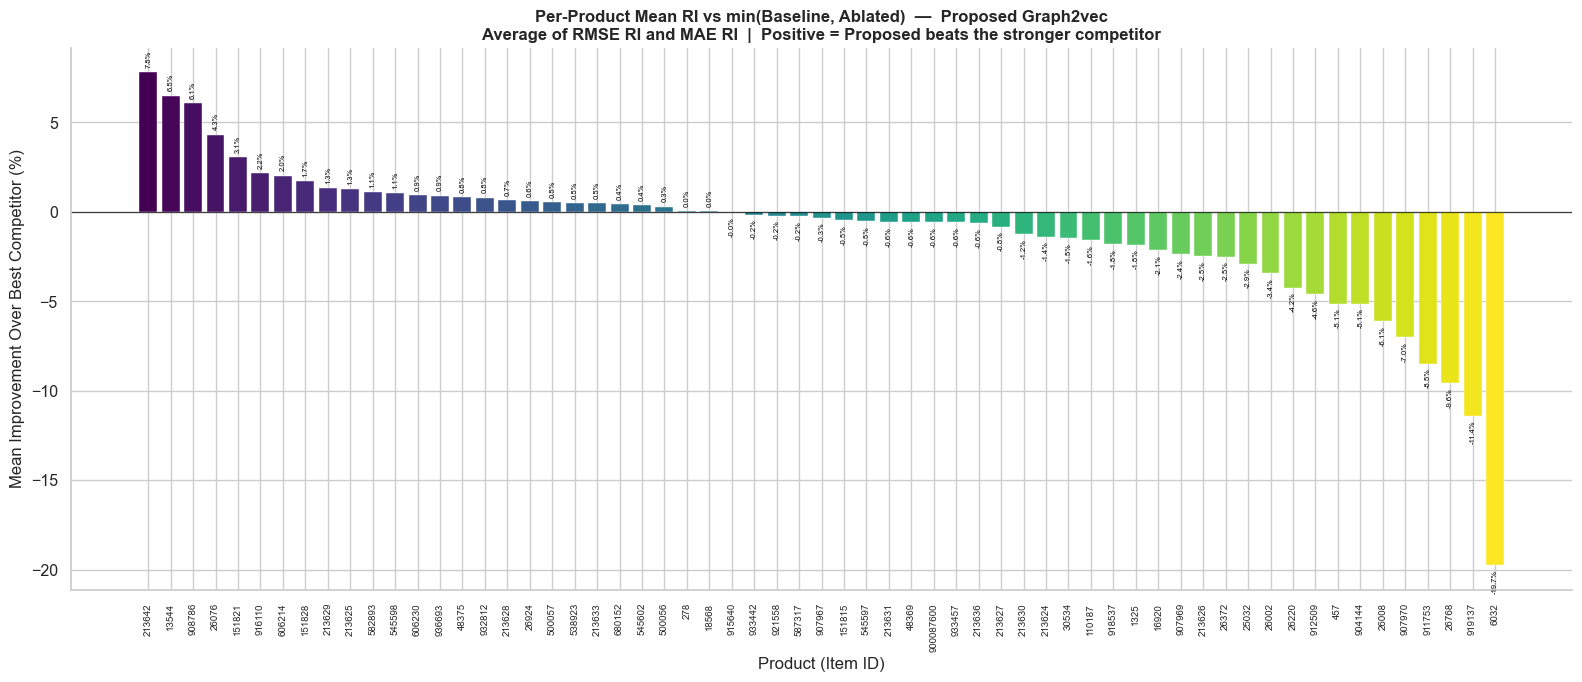

Saved → TimeDistributedMLP/fig_per_product_mean_ri.pdf
Products with positive RI : 26/61
Mean RI  : -1.0910%
Median RI: -0.3258%


In [37]:
import matplotlib.cm as cm

# ── Per-product data ──────────────────────────────────────────────────────────
agg_rows = []
for cond_df, label in [
    (BASELINE, 'baseline'),
    (ABLATED,  'ablated'),
    (PROPOSED, 'proposed'),
]:
    m = cond_df.groupby('item_id')[['rmse', 'mae']].mean()
    m.columns = [f'{c}_{label}' for c in m.columns]
    agg_rows.append(m)

prod_bar = pd.concat(agg_rows, axis=1).reset_index()
prod_bar['ref_rmse'] = prod_bar[['rmse_baseline', 'rmse_ablated']].min(axis=1)
prod_bar['ref_mae']  = prod_bar[['mae_baseline',  'mae_ablated']].min(axis=1)
prod_bar['RI_RMSE']  = (prod_bar['ref_rmse'] - prod_bar['rmse_proposed']) / prod_bar['ref_rmse'] * 100
prod_bar['RI_MAE']   = (prod_bar['ref_mae']  - prod_bar['mae_proposed'])  / prod_bar['ref_mae']  * 100
prod_bar['Mean_RI']  = (prod_bar['RI_RMSE'] + prod_bar['RI_MAE']) / 2
prod_bar = prod_bar.sort_values('Mean_RI', ascending=False).reset_index(drop=True)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 7))

n      = len(prod_bar)
colors = cm.viridis(np.linspace(0, 1, n))   # purple (best) → yellow (worst)

bars = ax.bar(
    range(n), prod_bar['Mean_RI'],
    color=colors, edgecolor='white', linewidth=0.3,
)

# Percentage annotation on each bar
for bar, val in zip(bars, prod_bar['Mean_RI']):
    va     = 'bottom' if val >= 0 else 'top'
    offset = 0.25     if val >= 0 else -0.25
    ax.text(
        bar.get_x() + bar.get_width() / 2, val + offset,
        f'{val:.1f}%', ha='center', va=va,
        fontsize=5.5, rotation=90, color='black',
    )

ax.axhline(0, color='black', linewidth=0.9, alpha=0.7)
ax.set_xticks(range(n))
ax.set_xticklabels(prod_bar['item_id'].astype(str), rotation=90, fontsize=7)
ax.set_xlabel('Product (Item ID)', fontsize=12)
ax.set_ylabel('Mean Improvement Over Best Competitor (%)', fontsize=12)
ax.set_title(
    'Per-Product Mean RI vs min(Baseline, Ablated)  —  Proposed Graph2vec\n'
    'Average of RMSE RI and MAE RI  |  Positive = Proposed beats the stronger competitor',
    fontsize=12, fontweight='bold',
)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig('TimeDistributedMLP/fig_per_product_mean_ri.pdf', bbox_inches='tight')
plt.show()

print(f"Saved → TimeDistributedMLP/fig_per_product_mean_ri.pdf")
print(f"Products with positive RI : {(prod_bar['Mean_RI'] > 0).sum()}/{n}")
print(f"Mean RI  : {prod_bar['Mean_RI'].mean():+.4f}%")
print(f"Median RI: {prod_bar['Mean_RI'].median():+.4f}%")


In [34]:
# ── Scale-invariant summary: distribution of per-product RI (%) ───────────────
agg_rows = []
for cond_df, label in [
    (BASELINE, 'baseline'),
    (ABLATED,  'ablated'),
    (PROPOSED, 'proposed'),
]:
    m = cond_df.groupby('item_id')[['rmse', 'mae']].mean()
    m.columns = [f'{c}_{label}' for c in m.columns]
    agg_rows.append(m)

prod = pd.concat(agg_rows, axis=1).reset_index()

prod['ref_rmse'] = prod[['rmse_baseline', 'rmse_ablated']].min(axis=1)
prod['ref_mae']  = prod[['mae_baseline',  'mae_ablated']].min(axis=1)
prod['RI_RMSE'] = (prod['ref_rmse'] - prod['rmse_proposed']) / prod['ref_rmse'] * 100
prod['RI_MAE']  = (prod['ref_mae']  - prod['mae_proposed'])  / prod['ref_mae']  * 100
prod['Mean_RI'] = (prod['RI_RMSE'] + prod['RI_MAE']) / 2

summary = pd.DataFrame({
    'Metric': ['RMSE RI (%)', 'MAE RI (%)', 'Mean RI (%)'],
    'Mean':   [prod['RI_RMSE'].mean(),  prod['RI_MAE'].mean(),  prod['Mean_RI'].mean()],
    'Median': [prod['RI_RMSE'].median(),prod['RI_MAE'].median(),prod['Mean_RI'].median()],
    'Std':    [prod['RI_RMSE'].std(),   prod['RI_MAE'].std(),   prod['Mean_RI'].std()],
    'Min':    [prod['RI_RMSE'].min(),   prod['RI_MAE'].min(),   prod['Mean_RI'].min()],
    'Max':    [prod['RI_RMSE'].max(),   prod['RI_MAE'].max(),   prod['Mean_RI'].max()],
    'Win rate (%)': [
        (prod['RI_RMSE'] > 0).mean() * 100,
        (prod['RI_MAE']  > 0).mean() * 100,
        (prod['Mean_RI'] > 0).mean() * 100,
    ],
})

display(summary.style
    .hide(axis='index')
    .format('{:+.4f}', subset=['Mean','Median','Std','Min','Max'])
    .format('{:.1f}%', subset=['Win rate (%)'])
    .background_gradient(subset=['Mean','Median'], cmap='RdYlGn', vmin=-5, vmax=5)
    .set_caption(
        "Scale-invariant summary — RI (%) of Proposed vs min(Baseline, Ablated). "
        "Each of 61 products contributes equally regardless of demand volume. "
        "Positive = Proposed beats the stronger competitor."
    )
)


Metric,Mean,Median,Std,Min,Max,Win rate (%)
RMSE RI (%),-0.9352,-0.3513,+4.3141,-21.8805,+10.1807,42.6%
MAE RI (%),-1.2467,-0.2031,+4.2235,-17.5901,+7.1312,42.6%
Mean RI (%),-1.0910,-0.3258,+4.1631,-19.7353,+7.7889,42.6%


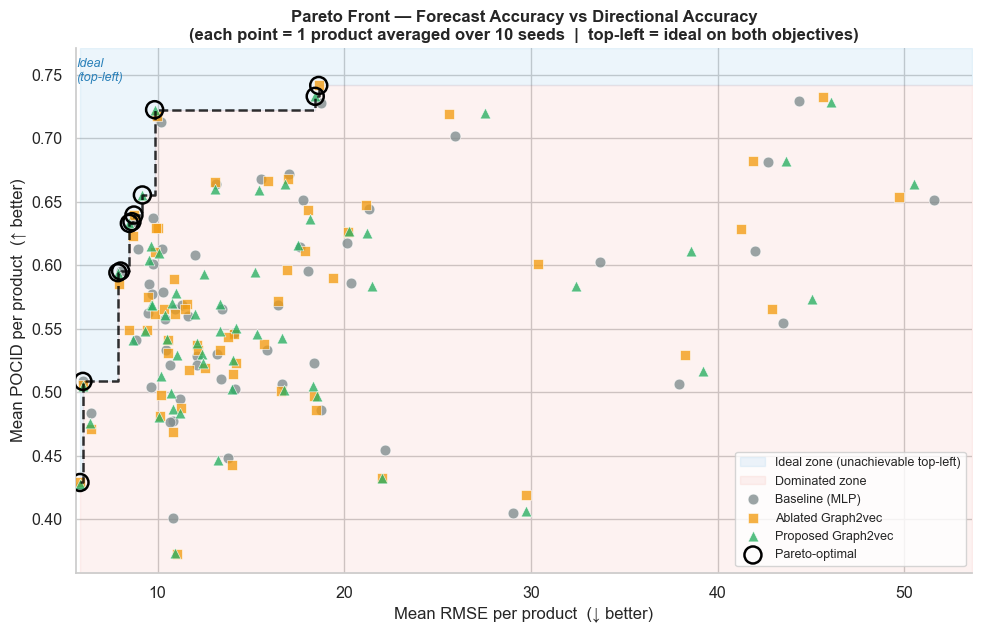

Saved → TimeDistributedMLP/fig_pareto_rmse_pocid.pdf

Pareto-optimal points by condition (total = 11):
condition
Ablated Graph2vec     3
Baseline (MLP)        3
Proposed Graph2vec    5


In [36]:
# ── Aggregate: one point per (product × condition) ───────────────────────────
specs = [
    (BASELINE, 'Baseline (MLP)',     '#7f8c8d', 'o'),
    (ABLATED,  'Ablated Graph2vec',  '#f39c12', 's'),
    (PROPOSED, 'Proposed Graph2vec', '#27ae60', '^'),
]

agg_rows = []
for cond_df, label, color, marker in specs:
    means = cond_df.groupby('item_id')[['rmse', 'pocid']].mean().reset_index()
    means['condition'] = label
    means['color']     = color
    means['marker']    = marker
    agg_rows.append(means)

all_pts = pd.concat(agg_rows, ignore_index=True)

# ── Pareto front: minimise RMSE ↓  AND  maximise POCID ↑ ─────────────────────
# Point i is dominated if ∃ j: rmse_j ≤ rmse_i  AND  pocid_j ≥ pocid_i  (≥1 strict)
def pareto_mask_min_max(df, min_col, max_col):
    vals = df[[min_col, max_col]].values
    n = len(vals)
    dominated = np.zeros(n, dtype=bool)
    for i in range(n):
        for j in range(n):
            if i != j \
               and vals[j, 0] <= vals[i, 0] and vals[j, 1] >= vals[i, 1] \
               and (vals[j, 0] < vals[i, 0] or vals[j, 1] > vals[i, 1]):
                dominated[i] = True
                break
    return ~dominated

all_pts['pareto'] = pareto_mask_min_max(all_pts, 'rmse', 'pocid')
# Sort by RMSE ascending — POCID increases along the front (you pay in accuracy to gain direction)
front = all_pts[all_pts['pareto']].sort_values('rmse').reset_index(drop=True)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6.5))
sns.set_theme(style='whitegrid', font_scale=1.05)

x_lo  = all_pts['rmse'].min()  * 0.96
x_max = all_pts['rmse'].max()  * 1.04
y_lo  = all_pts['pocid'].min() * 0.96
y_hi  = all_pts['pocid'].max() * 1.04

# Extend staircase to the right edge for fill_between
front_x = np.append(front['rmse'].values,  x_max)
front_y = np.append(front['pocid'].values, front['pocid'].values[-1])

# Blue = above staircase = ideal zone (low RMSE + high POCID) = unachievable top-left
ax.fill_between(front_x, front_y, y_hi, step='post',
                color='#3498db', alpha=0.09, zorder=1,
                label='Ideal zone (unachievable top-left)')

# Red = below staircase = dominated zone (high RMSE + low POCID)
ax.fill_between(front_x, y_lo, front_y, step='post',
                color='#e74c3c', alpha=0.07, zorder=1,
                label='Dominated zone')

# Staircase Pareto boundary
ax.step(front['rmse'], front['pocid'], where='post',
        color='black', linewidth=1.8, linestyle='--', alpha=0.8, zorder=4)

# Scatter all 183 points (61 products × 3 conditions)
for _, label, color, marker in specs:
    pts = all_pts[all_pts['condition'] == label]
    ax.scatter(pts['rmse'], pts['pocid'],
               label=label, color=color, marker=marker,
               s=60, alpha=0.78, edgecolors='white', linewidth=0.5, zorder=3)

# Ring the Pareto-optimal points
ax.scatter(front['rmse'], front['pocid'],
           s=150, facecolors='none', edgecolors='black',
           linewidths=1.8, zorder=5, label='Pareto-optimal')

# Annotate the ideal corner
ax.annotate('Ideal\n(top-left)', xy=(x_lo * 1.01, y_hi * 0.99),
            fontsize=9, color='#2980b9', fontstyle='italic',
            va='top', ha='left')

ax.set_xlim(x_lo, x_max)
ax.set_ylim(y_lo, y_hi)
ax.set_xlabel('Mean RMSE per product  (↓ better)', fontsize=12)
ax.set_ylabel('Mean POCID per product  (↑ better)', fontsize=12)
ax.set_title(
    'Pareto Front — Forecast Accuracy vs Directional Accuracy\n'
    '(each point = 1 product averaged over 10 seeds  |  top-left = ideal on both objectives)',
    fontsize=12, fontweight='bold',
)
ax.legend(frameon=True, fontsize=9, loc='lower right')
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig('TimeDistributedMLP/fig_pareto_rmse_pocid.pdf', bbox_inches='tight')
plt.show()

print("Saved → TimeDistributedMLP/fig_pareto_rmse_pocid.pdf")
print(f"\nPareto-optimal points by condition (total = {len(front)}):")
print(front.groupby('condition').size().rename('n_pareto_products').to_string())

In [41]:
display(front[['item_id', 'condition', 'rmse', 'pocid']]
    .rename(columns={'item_id': 'Product', 'condition': 'Condition',
                     'rmse': 'Mean RMSE', 'pocid': 'Mean POCID'})
    .style
    .hide(axis='index')
    .format({'Mean RMSE': '{:.4f}', 'Mean POCID': '{:.4f}'})
    .applymap(
        lambda v: 'color:#27ae60; font-weight:bold' if v == 'Proposed Graph2vec' else
                 ('color:#f39c12' if v == 'Ablated Graph2vec' else
                  ('color:#7f8c8d' if v == 'Baseline (MLP)' else '')),
        subset=['Condition']
    )
    .set_caption("Pareto-optimal products — RMSE vs POCID front")
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size','13px'), ('font-weight','bold')]},
        {'selector': 'th', 'props': [('text-align','center'), ('background-color','#2f527f'), ('color','white')]},
    ])
    .background_gradient(subset=['Mean RMSE'], cmap='Blues_r')
    .background_gradient(subset=['Mean POCID'], cmap='Greens')
)


Product,Condition,Mean RMSE,Mean POCID
921558,Ablated Graph2vec,5.8460,0.4289
587317,Baseline (MLP),6.0026,0.5086
606230,Proposed Graph2vec,7.8757,0.5941
606230,Baseline (MLP),8.0200,0.5954
916110,Proposed Graph2vec,8.4900,0.6329
916110,Baseline (MLP),8.6294,0.6342
916110,Ablated Graph2vec,8.7350,0.6395
907970,Proposed Graph2vec,9.1882,0.6553
213625,Proposed Graph2vec,9.8427,0.7224
213629,Proposed Graph2vec,18.4449,0.7329
